In [1]:
import numpy as np
import pandas as pd
from decimal import Decimal
import re

In [2]:
bitcoin_blocks = pd.read_csv("../data/real_bitcoin_blocks_raw.csv")
coinbase_addresses = pd.read_csv("../data/coinbase_addresses_full.csv")

In [3]:
# Formatting the real_outputs column data with regex and decimal conversion

# This regex restores the comma between entries before we hand the string to eval().
def parse_outputs(s):
    fixed = re.sub(r"\}\s*\n\s*\{", "}, {", s)
    return eval(fixed, {"Decimal": Decimal, "__builtins__": {}})

coinbase_addresses["real_outputs_parsed"] = coinbase_addresses["real_outputs"].apply(parse_outputs)
coinbase_addresses["n_addresses"] = coinbase_addresses["real_outputs_parsed"].apply(len)

In [4]:
coinbase_addresses['block_timestamp'] = pd.to_datetime(coinbase_addresses['block_timestamp'])
coinbase_addresses['block_timestamp'].describe()

count                              810909
mean     2016-05-13 12:52:27.924965+00:00
min             2009-01-03 18:15:05+00:00
25%             2012-10-10 22:19:35+00:00
50%             2016-04-02 20:55:40+00:00
75%             2019-12-15 06:03:40+00:00
max             2023-10-06 13:37:21+00:00
Name: block_timestamp, dtype: object

In [5]:
def get_primary_miner(coinbase_payouts):
    if coinbase_payouts == []:
        return (None, 0)
    
    highest_payout = max(coinbase_payouts, key=lambda x: x["value"])
    
    highest_payouts = []
    for payout in coinbase_payouts:
        if payout["value"] == highest_payout["value"]:
            highest_payouts.append(payout)
    
    return (highest_payouts[0]["address"], len(highest_payouts))

In [6]:
coinbase_addresses['primary_miner_result'] = coinbase_addresses['real_outputs_parsed'].apply(get_primary_miner)
coinbase_addresses['primary_miner_address'] = coinbase_addresses['primary_miner_result'].str[0]
coinbase_addresses['primary_miner_ties'] = coinbase_addresses['primary_miner_result'].str[1]
coinbase_addresses

,block_number,block_timestamp,real_outputs,real_outputs_parsed,n_addresses,primary_miner_result,primary_miner_address,primary_miner_ties
0,755688,2022-09-25 21:17:12+00:00,[{'address': '18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5...,[{'address': '18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5...,1,"(18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5PX, 1)",18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5PX,1
1,755658,2022-09-25 15:04:25+00:00,[{'address': '18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5...,[{'address': '18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5...,1,"(18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5PX, 1)",18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5PX,1
2,756371,2022-09-30 13:14:40+00:00,[{'address': '18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5...,[{'address': '18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5...,1,"(18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5PX, 1)",18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5PX,1
3,754843,2022-09-19 20:29:55+00:00,[{'address': '3L8Ck6bm3sve1vJGKo6Ht2k167YKSKi8...,[{'address': '3L8Ck6bm3sve1vJGKo6Ht2k167YKSKi8...,1,"(3L8Ck6bm3sve1vJGKo6Ht2k167YKSKi8TZ, 1)",3L8Ck6bm3sve1vJGKo6Ht2k167YKSKi8TZ,1
4,755220,2022-09-22 11:21:06+00:00,[{'address': '3C9sAKXrBVpJVe3b738yik4LPHpPmceB...,[{'address': '3C9sAKXrBVpJVe3b738yik4LPHpPmceB...,1,"(3C9sAKXrBVpJVe3b738yik4LPHpPmceBgd, 1)",3C9sAKXrBVpJVe3b738yik4LPHpPmceBgd,1
...,...,...,...,...,...,...,...,...
810904,762082,2022-11-07 04:51:06+00:00,[{'address': '12KKDt4Mj7N5UAkQMN7LtPZMayenXHa8...,[{'address': '12KKDt4Mj7N5UAkQMN7LtPZMayenXHa8...,1,"(12KKDt4Mj7N5UAkQMN7LtPZMayenXHa8KL, 1)",12KKDt4Mj7N5UAkQMN7LtPZMayenXHa8KL,1
810905,761961,2022-11-06 09:03:17+00:00,[{'address': '12KKDt4Mj7N5UAkQMN7LtPZMayenXHa8...,[{'address': '12KKDt4Mj7N5UAkQMN7LtPZMayenXHa8...,1,"(12KKDt4Mj7N5UAkQMN7LtPZMayenXHa8KL, 1)",12KKDt4Mj7N5UAkQMN7LtPZMayenXHa8KL,1
810906,763253,2022-11-15 08:27:13+00:00,[{'address': '12KKDt4Mj7N5UAkQMN7LtPZMayenXHa8...,[{'address': '12KKDt4Mj7N5UAkQMN7LtPZMayenXHa8...,1,"(12KKDt4Mj7N5UAkQMN7LtPZMayenXHa8KL, 1)",12KKDt4Mj7N5UAkQMN7LtPZMayenXHa8KL,1
810907,762893,2022-11-12 15:41:42+00:00,[{'address': '18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5...,[{'address': '18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5...,1,"(18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5PX, 1)",18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5PX,1


In [7]:
# join both dataframes
merged_df = pd.merge(bitcoin_blocks, coinbase_addresses, on='block_number', how='inner')
merged_df

,number,timestamp,size,transaction_count,bits,block_number,total_output_satoshis,total_output_satoshis_excl_coinbase,total_fee_satoshis,tx_count_check,difficulty,block_timestamp,real_outputs,real_outputs_parsed,n_addresses,primary_miner_result,primary_miner_address,primary_miner_ties
0,0,2009-01-03 18:15:05+00:00,285,1,1d00ffff,0,5.000000e+09,0.000000e+00,0.0,1,1.000000e+00,2009-01-03 18:15:05+00:00,[{'address': '1A1zP1eP5QGefi2DMPTfTL5SLmv7Divf...,[{'address': '1A1zP1eP5QGefi2DMPTfTL5SLmv7Divf...,1,"(1A1zP1eP5QGefi2DMPTfTL5SLmv7DivfNa, 1)",1A1zP1eP5QGefi2DMPTfTL5SLmv7DivfNa,1
1,1,2009-01-09 02:54:25+00:00,215,1,1d00ffff,1,5.000000e+09,0.000000e+00,0.0,1,1.000000e+00,2009-01-09 02:54:25+00:00,[{'address': '12c6DSiU4Rq3P4ZxziKxzrL5LmMBrzjr...,[{'address': '12c6DSiU4Rq3P4ZxziKxzrL5LmMBrzjr...,1,"(12c6DSiU4Rq3P4ZxziKxzrL5LmMBrzjrJX, 1)",12c6DSiU4Rq3P4ZxziKxzrL5LmMBrzjrJX,1
2,2,2009-01-09 02:55:44+00:00,215,1,1d00ffff,2,5.000000e+09,0.000000e+00,0.0,1,1.000000e+00,2009-01-09 02:55:44+00:00,[{'address': '1HLoD9E4SDFFPDiYfNYnkBLQ85Y51J3Z...,[{'address': '1HLoD9E4SDFFPDiYfNYnkBLQ85Y51J3Z...,1,"(1HLoD9E4SDFFPDiYfNYnkBLQ85Y51J3Zb1, 1)",1HLoD9E4SDFFPDiYfNYnkBLQ85Y51J3Zb1,1
3,3,2009-01-09 03:02:53+00:00,215,1,1d00ffff,3,5.000000e+09,0.000000e+00,0.0,1,1.000000e+00,2009-01-09 03:02:53+00:00,[{'address': '1FvzCLoTPGANNjWoUo6jUGuAG3wg1w4Y...,[{'address': '1FvzCLoTPGANNjWoUo6jUGuAG3wg1w4Y...,1,"(1FvzCLoTPGANNjWoUo6jUGuAG3wg1w4YjR, 1)",1FvzCLoTPGANNjWoUo6jUGuAG3wg1w4YjR,1
4,4,2009-01-09 03:16:28+00:00,215,1,1d00ffff,4,5.000000e+09,0.000000e+00,0.0,1,1.000000e+00,2009-01-09 03:16:28+00:00,[{'address': '15ubicBBWFnvoZLT7GiU2qxjRaKJPdkD...,[{'address': '15ubicBBWFnvoZLT7GiU2qxjRaKJPdkD...,1,"(15ubicBBWFnvoZLT7GiU2qxjRaKJPdkDMG, 1)",15ubicBBWFnvoZLT7GiU2qxjRaKJPdkDMG,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
810904,810904,2023-10-06 12:36:45+00:00,1471359,2641,1704e90f,810904,7.607876e+11,7.601375e+11,25173010.0,2641,5.732151e+13,2023-10-06 12:36:45+00:00,[{'address': 'bc1qxhmdufsvnuaaaer4ynz88fspdsxq...,[{'address': 'bc1qxhmdufsvnuaaaer4ynz88fspdsxq...,1,"(bc1qxhmdufsvnuaaaer4ynz88fspdsxq2h9e9cetdj, 1)",bc1qxhmdufsvnuaaaer4ynz88fspdsxq2h9e9cetdj,1
810905,810905,2023-10-06 12:45:49+00:00,1427754,2288,1704e90f,810905,1.161340e+12,1.160692e+12,23663392.0,2288,5.732151e+13,2023-10-06 12:45:49+00:00,[{'address': 'bc1qxhmdufsvnuaaaer4ynz88fspdsxq...,[{'address': 'bc1qxhmdufsvnuaaaer4ynz88fspdsxq...,1,"(bc1qxhmdufsvnuaaaer4ynz88fspdsxq2h9e9cetdj, 1)",bc1qxhmdufsvnuaaaer4ynz88fspdsxq2h9e9cetdj,1
810906,810906,2023-10-06 12:50:15+00:00,1612966,2016,1704e90f,810906,4.643628e+11,4.637224e+11,15483511.0,2016,5.732151e+13,2023-10-06 12:50:15+00:00,[{'address': '1K6KoYC69NnafWJ7YgtrpwJxBLiijWqw...,[{'address': '1K6KoYC69NnafWJ7YgtrpwJxBLiijWqw...,2,"(1KFHE7w8BhaENAswwryaoccDb6qcT6DbYY, 1)",1KFHE7w8BhaENAswwryaoccDb6qcT6DbYY,1
810907,810907,2023-10-06 13:37:00+00:00,1486563,3496,1704e90f,810907,2.469789e+12,2.469101e+12,63223285.0,3496,5.732151e+13,2023-10-06 13:37:00+00:00,[{'address': '38XnPvu9PmonFU9WouPXUjYbW91wa5Me...,[{'address': '38XnPvu9PmonFU9WouPXUjYbW91wa5Me...,1,"(38XnPvu9PmonFU9WouPXUjYbW91wa5MerL, 1)",38XnPvu9PmonFU9WouPXUjYbW91wa5MerL,1


In [8]:
miner_block_counts = merged_df['primary_miner_address'].value_counts()
print(miner_block_counts)


primary_miner_address
1KFHE7w8BhaENAswwryaoccDb6qcT6DbYY            81237
18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5PX            34093
1CK6KHY6MHgYvmRQ4PAafKYDrg1ejbH1cE            27261
14cZMQk89mRYQkDEj8Rn25AnGoBi5H6uer            26204
1CjPR7Z5ZSyWk6WtXvSFgkptmpoi4UM9BC            23083
                                              ...  
3EHpvbs5ar7DWiux1AQ5JMB2zTBE6wzX7d                1
bc1qrm09asqsxh2l7pjxjlltm53tx689dp2amzupzq        1
bc1q6fu02uvz2ghz3e3avqvqsqscr2pp4xhnuqfxpa        1
bc1q2za4ejga366sn288273pty8trasn5zs4y9hqg6        1
15h4MFgMs3yGiGfXA7fqhpsTWMkQ95EFBB                1
Name: count, Length: 197095, dtype: int64


In [9]:
# Step A: for every row, look up how many blocks its own address has mined in total
# .map() works like a dictionary lookup applied to an entire column at once,
# and importantly, unlike direct indexing, .map() quietly returns NaN for addresses
# it can't find (like our two None addresses), instead of crashing
merged_df['own_block_count'] = merged_df['primary_miner_address'].map(miner_block_counts)

# Step B: for every row, decide: keep the real address if count >= 10, otherwise 'long_tail'
merged_df['miner_group'] = np.where(merged_df['own_block_count'] >= 10, merged_df['primary_miner_address'], 'long_tail')

merged_df

,number,timestamp,size,transaction_count,bits,block_number,total_output_satoshis,total_output_satoshis_excl_coinbase,total_fee_satoshis,tx_count_check,difficulty,block_timestamp,real_outputs,real_outputs_parsed,n_addresses,primary_miner_result,primary_miner_address,primary_miner_ties,own_block_count,miner_group
0,0,2009-01-03 18:15:05+00:00,285,1,1d00ffff,0,5.000000e+09,0.000000e+00,0.0,1,1.000000e+00,2009-01-03 18:15:05+00:00,[{'address': '1A1zP1eP5QGefi2DMPTfTL5SLmv7Divf...,[{'address': '1A1zP1eP5QGefi2DMPTfTL5SLmv7Divf...,1,"(1A1zP1eP5QGefi2DMPTfTL5SLmv7DivfNa, 1)",1A1zP1eP5QGefi2DMPTfTL5SLmv7DivfNa,1,1.0,long_tail
1,1,2009-01-09 02:54:25+00:00,215,1,1d00ffff,1,5.000000e+09,0.000000e+00,0.0,1,1.000000e+00,2009-01-09 02:54:25+00:00,[{'address': '12c6DSiU4Rq3P4ZxziKxzrL5LmMBrzjr...,[{'address': '12c6DSiU4Rq3P4ZxziKxzrL5LmMBrzjr...,1,"(12c6DSiU4Rq3P4ZxziKxzrL5LmMBrzjrJX, 1)",12c6DSiU4Rq3P4ZxziKxzrL5LmMBrzjrJX,1,1.0,long_tail
2,2,2009-01-09 02:55:44+00:00,215,1,1d00ffff,2,5.000000e+09,0.000000e+00,0.0,1,1.000000e+00,2009-01-09 02:55:44+00:00,[{'address': '1HLoD9E4SDFFPDiYfNYnkBLQ85Y51J3Z...,[{'address': '1HLoD9E4SDFFPDiYfNYnkBLQ85Y51J3Z...,1,"(1HLoD9E4SDFFPDiYfNYnkBLQ85Y51J3Zb1, 1)",1HLoD9E4SDFFPDiYfNYnkBLQ85Y51J3Zb1,1,1.0,long_tail
3,3,2009-01-09 03:02:53+00:00,215,1,1d00ffff,3,5.000000e+09,0.000000e+00,0.0,1,1.000000e+00,2009-01-09 03:02:53+00:00,[{'address': '1FvzCLoTPGANNjWoUo6jUGuAG3wg1w4Y...,[{'address': '1FvzCLoTPGANNjWoUo6jUGuAG3wg1w4Y...,1,"(1FvzCLoTPGANNjWoUo6jUGuAG3wg1w4YjR, 1)",1FvzCLoTPGANNjWoUo6jUGuAG3wg1w4YjR,1,1.0,long_tail
4,4,2009-01-09 03:16:28+00:00,215,1,1d00ffff,4,5.000000e+09,0.000000e+00,0.0,1,1.000000e+00,2009-01-09 03:16:28+00:00,[{'address': '15ubicBBWFnvoZLT7GiU2qxjRaKJPdkD...,[{'address': '15ubicBBWFnvoZLT7GiU2qxjRaKJPdkD...,1,"(15ubicBBWFnvoZLT7GiU2qxjRaKJPdkDMG, 1)",15ubicBBWFnvoZLT7GiU2qxjRaKJPdkDMG,1,1.0,long_tail
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
810904,810904,2023-10-06 12:36:45+00:00,1471359,2641,1704e90f,810904,7.607876e+11,7.601375e+11,25173010.0,2641,5.732151e+13,2023-10-06 12:36:45+00:00,[{'address': 'bc1qxhmdufsvnuaaaer4ynz88fspdsxq...,[{'address': 'bc1qxhmdufsvnuaaaer4ynz88fspdsxq...,1,"(bc1qxhmdufsvnuaaaer4ynz88fspdsxq2h9e9cetdj, 1)",bc1qxhmdufsvnuaaaer4ynz88fspdsxq2h9e9cetdj,1,14480.0,bc1qxhmdufsvnuaaaer4ynz88fspdsxq2h9e9cetdj
810905,810905,2023-10-06 12:45:49+00:00,1427754,2288,1704e90f,810905,1.161340e+12,1.160692e+12,23663392.0,2288,5.732151e+13,2023-10-06 12:45:49+00:00,[{'address': 'bc1qxhmdufsvnuaaaer4ynz88fspdsxq...,[{'address': 'bc1qxhmdufsvnuaaaer4ynz88fspdsxq...,1,"(bc1qxhmdufsvnuaaaer4ynz88fspdsxq2h9e9cetdj, 1)",bc1qxhmdufsvnuaaaer4ynz88fspdsxq2h9e9cetdj,1,14480.0,bc1qxhmdufsvnuaaaer4ynz88fspdsxq2h9e9cetdj
810906,810906,2023-10-06 12:50:15+00:00,1612966,2016,1704e90f,810906,4.643628e+11,4.637224e+11,15483511.0,2016,5.732151e+13,2023-10-06 12:50:15+00:00,[{'address': '1K6KoYC69NnafWJ7YgtrpwJxBLiijWqw...,[{'address': '1K6KoYC69NnafWJ7YgtrpwJxBLiijWqw...,2,"(1KFHE7w8BhaENAswwryaoccDb6qcT6DbYY, 1)",1KFHE7w8BhaENAswwryaoccDb6qcT6DbYY,1,81237.0,1KFHE7w8BhaENAswwryaoccDb6qcT6DbYY
810907,810907,2023-10-06 13:37:00+00:00,1486563,3496,1704e90f,810907,2.469789e+12,2.469101e+12,63223285.0,3496,5.732151e+13,2023-10-06 13:37:00+00:00,[{'address': '38XnPvu9PmonFU9WouPXUjYbW91wa5Me...,[{'address': '38XnPvu9PmonFU9WouPXUjYbW91wa5Me...,1,"(38XnPvu9PmonFU9WouPXUjYbW91wa5MerL, 1)",38XnPvu9PmonFU9WouPXUjYbW91wa5MerL,1,15630.0,38XnPvu9PmonFU9WouPXUjYbW91wa5MerL


In [10]:
merged_df['miner_group'].value_counts()

miner_group
long_tail                             200987
1KFHE7w8BhaENAswwryaoccDb6qcT6DbYY     81237
18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5PX     34093
1CK6KHY6MHgYvmRQ4PAafKYDrg1ejbH1cE     27261
14cZMQk89mRYQkDEj8Rn25AnGoBi5H6uer     26204
                                       ...  
1s2mUUUUGHzBsEy9p8CEUW82impM3fnav         10
1MVA4tCYxtCmfq5fz4LoiYTwWKaeB6LPEx        10
13WmMzyrJxfJAgWupbQGqCn9YeNQo2gJAW        10
12ybPxJQqJMFQK24Gszz8TdC1tJjWCm3Ch        10
1ZULUPooLEQfkrTgynLV4uHyMgQYx71ip         10
Name: count, Length: 976, dtype: int64

In [11]:
comparison = merged_df.groupby('miner_group').agg(
    n_blocks=('block_number', 'count'),
    avg_transactions=('transaction_count', 'mean'),
    avg_volume=('total_output_satoshis_excl_coinbase', 'mean'),
    avg_size=('size', 'mean'),
    avg_difficulty=('difficulty', 'mean'),
).reset_index()

comparison

,miner_group,n_blocks,avg_transactions,avg_volume,avg_size,avg_difficulty
0,112th1SmjAKALwtpsdXuYQ4Uu8e9rbwEXt,20,307.800000,4.934083e+11,1.454196e+05,1.364458e+09
1,1134jVdutTZpDfsPjLu4U1vE3UURdWeFui,15,1122.666667,1.408473e+12,1.050330e+06,2.686701e+12
2,115ZtZBrhso9PbHBUh44gf6ycxmoHHEFp1,516,276.662791,5.837774e+12,1.172129e+05,2.775592e+06
3,11wC5KcbgrWRBb43cwADdVrxgyF8mndVC,92,2248.413043,1.166347e+12,1.201610e+06,1.753234e+13
4,122Z63d9uRgYaAugxawaB79o12fRNYwFc8,125,905.792000,7.013965e+11,4.629104e+05,3.638500e+12
...,...,...,...,...,...,...
971,bc1qvfzssz36y4gxcg9gh234rzem9k0vrdlx4kq5sg,96,2958.635417,5.716535e+11,1.741142e+06,5.147298e+13
972,bc1qwlrsvgtn99rqp3fgaxq6f6jkgms80rnej0a8tc,71,2122.281690,1.071779e+12,1.323265e+06,2.210247e+13
973,bc1qx9t2l3pyny2spqpqlye8svce70nppwtaxwdrp4,4701,1915.912146,1.615549e+12,1.227302e+06,1.937132e+13
974,bc1qxhmdufsvnuaaaer4ynz88fspdsxq2h9e9cetdj,14480,2590.779075,5.855246e+11,1.668432e+06,4.631282e+13


In [12]:
comparison.sort_values('n_blocks', ascending=False).reset_index()

,index,miner_group,n_blocks,avg_transactions,avg_volume,avg_size,avg_difficulty
0,975,long_tail,200987,53.730097,3.767628e+11,2.618385e+04,4.692112e+10
1,660,1KFHE7w8BhaENAswwryaoccDb6qcT6DbYY,81237,1572.123860,1.223580e+12,9.029435e+05,1.131776e+13
2,250,18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5PX,34093,1918.849119,1.415265e+12,1.132617e+06,1.671824e+13
3,394,1CK6KHY6MHgYvmRQ4PAafKYDrg1ejbH1cE,27261,1740.016984,1.361256e+12,9.669289e+05,9.667326e+12
4,104,14cZMQk89mRYQkDEj8Rn25AnGoBi5H6uer,26204,384.621737,6.967644e+11,1.992497e+05,4.461016e+09
...,...,...,...,...,...,...,...
971,643,1JqyZ1ZyXGeuYVtW6Rdb3pUyr1Rzovjsai,10,1317.900000,1.528522e+12,9.985185e+05,6.114054e+11
972,653,1K5mkSvF6hCKktrXpe4aqL24kuYkNu1DrB,10,219.900000,1.624221e+11,1.776496e+05,3.466143e+10
973,179,16aCWzQW4EiDKuzqfFZDtZ7B8Jo5uNG2mt,10,781.900000,9.286592e+11,4.527701e+05,3.701776e+10
974,372,1BhJddEW2neo87ANjw1NKfXtXtZQpyLHAD,10,281.400000,1.892580e+11,2.249596e+05,1.175655e+10


### Comparing  (>= 10 Blocks)  and (< 10 Blocks) Miners

In [13]:
df1 = comparison.describe()
df1

,n_blocks,avg_transactions,avg_volume,avg_size,avg_difficulty
count,976.000000,976.000000,9.760000e+02,9.760000e+02,9.760000e+02
mean,830.849385,939.210486,1.033673e+12,5.224072e+05,4.277221e+12
std,7315.834144,795.373197,1.488880e+12,4.520810e+05,9.184461e+12
min,10.000000,3.933333,7.002614e+09,2.925067e+03,1.574164e+05
25%,15.000000,285.295674,4.583670e+11,1.419660e+05,1.874589e+08
50%,38.000000,560.971861,7.514152e+11,3.335523e+05,3.978064e+10
75%,168.000000,1762.025805,1.354585e+12,9.663208e+05,3.660821e+12
max,200987.000000,3190.382413,3.895685e+13,2.254906e+06,5.371538e+13


In [14]:
# describe without 'long_tail' row
df2 = comparison[comparison['miner_group'] != 'long_tail'].describe()
df2

,n_blocks,avg_transactions,avg_volume,avg_size,avg_difficulty
count,975.000000,975.000000,9.750000e+02,9.750000e+02,9.750000e+02
mean,625.561026,940.118671,1.034346e+12,5.229162e+05,4.281559e+12
std,3521.686866,795.274919,1.489495e+12,4.520332e+05,9.188173e+12
min,10.000000,3.933333,7.002614e+09,2.925067e+03,1.574164e+05
25%,15.000000,285.956342,4.585723e+11,1.420620e+05,1.854632e+08
50%,38.000000,561.181818,7.525184e+11,3.338283e+05,3.960367e+10
75%,167.500000,1763.088085,1.354779e+12,9.663877e+05,3.683142e+12
max,81237.000000,3190.382413,3.895685e+13,2.254906e+06,5.371538e+13


In [15]:
mismatches = df1.compare(df2)
mismatches

n_blocks               avg_transactions               \
                self         other             self        other   
count     976.000000    975.000000       976.000000   975.000000   
mean      830.849385    625.561026       939.210486   940.118671   
std      7315.834144   3521.686866       795.373197   795.274919   
25%              NaN           NaN       285.295674   285.956342   
50%              NaN           NaN       560.971861   561.181818   
75%       168.000000    167.500000      1762.025805  1763.088085   
max    200987.000000  81237.000000              NaN          NaN   

         avg_volume                     avg_size                 \
               self         other           self          other   
count  9.760000e+02  9.750000e+02     976.000000     975.000000   
mean   1.033673e+12  1.034346e+12  522407.223147  522916.170191   
std    1.488880e+12  1.489495e+12  452081.012329  452033.189714   
25%    4.583670e+11  4.585723e+11  141966.021429  142062.030005   
50%    7.514152e+11  7.525184e+11  333552.347222  333828.333333   
75%    1.354585e+12  1.354779e+12  966320.763594  966387.708493   
max             NaN           NaN            NaN            NaN   

      avg_difficulty                
                self         other  
count   9.760000e+02  9.750000e+02  
mean    4.277221e+12  4.281559e+12  
std     9.184461e+12  9.188173e+12  
25%     1.874589e+08  1.854632e+08  
50%     3.978064e+10  3.960367e+10  
75%     3.660821e+12  3.683142e+12  
max              NaN           NaN

In [16]:
# since long_tail statistics are mostly below the 25th percentile,
# check if it's mostly from the early era of blocks
merged_df['timestamp'] = pd.to_datetime(merged_df['timestamp'])

is_long_tail = merged_df['miner_group'] == 'long_tail'

print("long_tail blocks:")
print(merged_df.loc[is_long_tail, 'timestamp'].describe())

print("\nreal-miner blocks:")
print(merged_df.loc[~is_long_tail, 'timestamp'].describe())

# confirmed that the long_tail of <10 blocks miners are mostly from early era bitcoin
# there are still some low block miners in every year
# (may be caused by miners only using an address once and switching)

long_tail blocks:
count                              200987
mean     2011-02-21 08:53:09.961022+00:00
min             2009-01-03 18:15:05+00:00
25%             2010-04-11 16:37:43+00:00
50%             2011-01-01 11:42:28+00:00
75%      2011-10-30 05:34:15.500000+00:00
max             2023-10-05 07:29:38+00:00
Name: timestamp, dtype: object

real-miner blocks:
count                              609922
mean     2018-02-01 07:58:53.960064+00:00
min             2011-04-29 17:34:22+00:00
25%      2015-04-12 11:54:31.750000+00:00
50%      2018-01-21 19:24:24.500000+00:00
75%      2020-11-23 01:41:11.500000+00:00
max             2023-10-06 13:37:21+00:00
Name: timestamp, dtype: object


## Data Preparation, Model Training and Testing

### Step 0: Patch the one zero-volume block

In [17]:
# note: only 1 block had 0 in total_output_satoshis
# fill all 0 values with the median total_output_satoshis 
merged_df['total_output_satoshis'] = merged_df['total_output_satoshis'].replace(0, np.nan)
merged_df['total_output_satoshis'] = merged_df['total_output_satoshis'].fillna(merged_df['total_output_satoshis'].median())

### Step 1: The feature-building function

In [18]:
def build_miner_features(data, group_col='miner_group', drop_long_tail=False):
    df = data.copy()
    if drop_long_tail:
        df = df[df[group_col] != 'long_tail'].copy()

    # per-block ratio, needed later for the mean_of_ratios efficiency definition
    df['block_efficiency'] = df['transaction_count'] / df['total_output_satoshis']

    # the existing pipeline's fee approximation (kept for comparability)
    df['fee_proxy'] = df['transaction_count'] * df['total_output_satoshis']

    miner_df = df.groupby(group_col).agg(
        blocks_mined=('block_number', 'count'),
        avg_transactions=('transaction_count', 'mean'),
        avg_volume=('total_output_satoshis', 'mean'),
        avg_block_size=('size', 'mean'),
        difficulty=('difficulty', 'mean'),
        mean_of_ratios_efficiency=('block_efficiency', 'mean'),
        avg_fee_proxy=('fee_proxy', 'mean'),
        fee_volatility_proxy=('fee_proxy', 'std'),
        profitability_proxy=('fee_proxy', 'sum'),
        avg_fee_real=('total_fee_satoshis', 'mean'),
        fee_volatility_real=('total_fee_satoshis', 'std'),
        profitability_real=('total_fee_satoshis', 'sum'),
        last_block_time=('timestamp', 'max'),
    ).reset_index().rename(columns={group_col: 'miner_id'})

    # match the existing pipeline's profitability adjustment (sum / (blocks_mined + 1))
    miner_df['profitability_proxy'] = miner_df['profitability_proxy'] / (miner_df['blocks_mined'] + 1)
    miner_df['profitability_real'] = miner_df['profitability_real'] / (miner_df['blocks_mined'] + 1)

    # ratio_of_means efficiency: computed from the already-averaged columns, not per-block
    miner_df['ratio_of_means_efficiency'] = miner_df['avg_transactions'] / (miner_df['avg_volume'] + 1e-9)

    # neighbor_gap age: sort miners by their last-mined time, gap to whoever's right before them
    sorted_miners = miner_df.sort_values('last_block_time').reset_index(drop=True)
    sorted_miners['age'] = sorted_miners['last_block_time'].diff().dt.total_seconds()
    sorted_miners['age'] = sorted_miners['age'].fillna(sorted_miners['age'].median())
    miner_df = miner_df.merge(sorted_miners[['miner_id', 'age']], on='miner_id')

    return miner_df

### Step 2: Build both feature tables

In [19]:
bucket_features = build_miner_features(merged_df, drop_long_tail=False)
drop_features = build_miner_features(merged_df, drop_long_tail=True)

### Step 3: Add labels for both efficiency definitions

In [20]:
def add_label(miner_df, efficiency_col, label_col):
    median_eff = miner_df[efficiency_col].median()
    miner_df[label_col] = (miner_df[efficiency_col] > median_eff).astype(int)

for df_ in [bucket_features, drop_features]:
    add_label(df_, 'ratio_of_means_efficiency', 'label_rom')
    add_label(df_, 'mean_of_ratios_efficiency', 'label_mor')

### Step 4: The model-running function

In [21]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

def run_pipeline(miner_df, feature_columns, label_col, seed=42):
    X = miner_df[feature_columns]
    y = miner_df[label_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = MLPClassifier(
        hidden_layer_sizes=(64, 32, 16, 8), activation='relu', solver='adam',
        alpha=0.001, random_state=seed, early_stopping=True,
        validation_fraction=0.1, n_iter_no_change=20, max_iter=100, batch_size=16
    )
    model.fit(X_train_scaled, y_train)

    test_acc = accuracy_score(y_test, model.predict(X_test_scaled))
    cv_mean = cross_val_score(model, X_train_scaled, y_train, cv=5).mean()

    return test_acc, cv_mean

### Step 5: Run all 8 configurations and collect results

In [22]:
feature_sets = {
    'proxy_fee': ['blocks_mined', 'avg_transactions', 'avg_volume', 'avg_fee_proxy',
                  'fee_volatility_proxy', 'avg_block_size', 'difficulty', 'profitability_proxy', 'age'],
    'real_fee': ['blocks_mined', 'avg_transactions', 'avg_volume', 'avg_fee_real',
                 'fee_volatility_real', 'avg_block_size', 'difficulty', 'profitability_real', 'age'],
}

feature_sets_reduced = {
    'proxy_fee': ['blocks_mined', 'avg_fee_proxy', 'fee_volatility_proxy',
                  'avg_block_size', 'difficulty', 'profitability_proxy', 'age'],
    'real_fee': ['blocks_mined', 'avg_fee_real', 'fee_volatility_real',
                 'avg_block_size', 'difficulty', 'profitability_real', 'age'],
}

label_cols = {'ratio_of_means': 'label_rom', 'mean_of_ratios': 'label_mor'}
grouping_schemes = {'bucket': bucket_features, 'drop': drop_features}

In [23]:
# test the model with full feature set
results = []
for grouping_name, miner_df in grouping_schemes.items():
    for fee_name, feature_cols in feature_sets.items():
        for eff_name, label_col in label_cols.items():
            test_acc, cv_mean = run_pipeline(miner_df, feature_cols, label_col)
            results.append({
                'grouping': grouping_name, 'fee_measure': fee_name, 'efficiency': eff_name,
                'test_accuracy': test_acc, 'cv_mean': cv_mean, 'n_miners': len(miner_df)
            })

results_df = pd.DataFrame(results)
results_df

,grouping,fee_measure,efficiency,test_accuracy,cv_mean,n_miners
0,bucket,proxy_fee,ratio_of_means,0.943878,0.943590,976
1,bucket,proxy_fee,mean_of_ratios,0.882653,0.874359,976
2,bucket,real_fee,ratio_of_means,0.948980,0.953846,976
3,bucket,real_fee,mean_of_ratios,0.882653,0.882051,976
4,drop,proxy_fee,ratio_of_means,0.958974,0.960256,975
5,drop,proxy_fee,mean_of_ratios,0.887179,0.892308,975
6,drop,real_fee,ratio_of_means,0.948718,0.965385,975
7,drop,real_fee,mean_of_ratios,0.887179,0.885897,975


In [24]:
# test the model with reduced feature set
results_reduced = []
for grouping_name, miner_df in grouping_schemes.items():
    for fee_name, feature_cols in feature_sets_reduced.items():
        for eff_name, label_col in label_cols.items():
            test_acc, cv_mean = run_pipeline(miner_df, feature_cols, label_col)
            results_reduced.append({
                'grouping': grouping_name, 'fee_measure': fee_name, 'efficiency': eff_name,
                'test_accuracy': test_acc, 'cv_mean': cv_mean, 'n_miners': len(miner_df)
            })

results_reduced_df = pd.DataFrame(results_reduced)
results_reduced_df

,grouping,fee_measure,efficiency,test_accuracy,cv_mean,n_miners
0,bucket,proxy_fee,ratio_of_means,0.882653,0.861538,976
1,bucket,proxy_fee,mean_of_ratios,0.862245,0.841026,976
2,bucket,real_fee,ratio_of_means,0.780612,0.817949,976
3,bucket,real_fee,mean_of_ratios,0.816327,0.856410,976
4,drop,proxy_fee,ratio_of_means,0.887179,0.874359,975
5,drop,proxy_fee,mean_of_ratios,0.907692,0.856410,975
6,drop,real_fee,ratio_of_means,0.800000,0.839744,975
7,drop,real_fee,mean_of_ratios,0.835897,0.819231,975


## Analysing data skew

### Check Skew and Min Values

In [25]:
print(bucket_features[feature_sets_reduced['proxy_fee']].skew())
print(bucket_features[feature_sets_reduced['real_fee']].skew())

blocks_mined            22.703441
avg_fee_proxy            3.826786
fee_volatility_proxy     8.668703
avg_block_size           0.733748
difficulty               2.834933
profitability_proxy      3.514664
age                      4.921510
dtype: float64
blocks_mined           22.703441
avg_fee_real            3.609558
fee_volatility_real    15.977721
avg_block_size          0.733748
difficulty              2.834933
profitability_real      3.543607
age                     4.921510
dtype: float64


In [26]:
print(drop_features[feature_sets_reduced['proxy_fee']].skew())
print(drop_features[feature_sets_reduced['real_fee']].skew())

blocks_mined            15.035409
avg_fee_proxy            3.826464
fee_volatility_proxy     8.664621
avg_block_size           0.732712
difficulty               2.833091
profitability_proxy      3.514235
age                      4.919886
dtype: float64
blocks_mined           15.035409
avg_fee_real            3.607983
fee_volatility_real    15.969772
avg_block_size          0.732712
difficulty              2.833091
profitability_real      3.542021
age                     4.919886
dtype: float64


In [27]:
print(bucket_features[feature_sets_reduced['proxy_fee']].min())
print(bucket_features[feature_sets_reduced['real_fee']].min())

blocks_mined            1.000000e+01
avg_fee_proxy           1.083209e+11
fee_volatility_proxy    1.241486e+11
avg_block_size          2.925067e+03
difficulty              1.574164e+05
profitability_proxy     9.929420e+10
age                     2.100000e+01
dtype: float64
blocks_mined               10.000000
avg_fee_real           517956.100000
fee_volatility_real    151609.532279
avg_block_size           2925.066667
difficulty             157416.401844
profitability_real     470869.181818
age                        21.000000
dtype: float64


In [28]:
print(drop_features[feature_sets_reduced['proxy_fee']].min())
print(drop_features[feature_sets_reduced['real_fee']].min())

blocks_mined            1.000000e+01
avg_fee_proxy           1.083209e+11
fee_volatility_proxy    1.241486e+11
avg_block_size          2.925067e+03
difficulty              1.574164e+05
profitability_proxy     9.929420e+10
age                     2.100000e+01
dtype: float64
blocks_mined               10.000000
avg_fee_real           517956.100000
fee_volatility_real    151609.532279
avg_block_size           2925.066667
difficulty             157416.401844
profitability_real     470869.181818
age                        21.000000
dtype: float64


### Run Training and Tests with transformations applied to columns

#### log1p for all columns

In [29]:
log_cols_map = {
    'proxy_fee': ['blocks_mined', 'avg_fee_proxy', 'fee_volatility_proxy', 'difficulty', 'profitability_proxy', 'age'],
    'real_fee': ['blocks_mined', 'avg_fee_real', 'fee_volatility_real', 'difficulty', 'profitability_real', 'age'],
}

print("=== Skew comparison: before vs after log1p ===\n")

for grouping_name, miner_df in grouping_schemes.items():
    for fee_name, feature_cols in feature_sets_reduced.items():
        cols_to_log = log_cols_map[fee_name]

        before = miner_df[cols_to_log].skew()

        df_log = miner_df.copy()
        df_log[cols_to_log] = np.log1p(df_log[cols_to_log])
        after = df_log[cols_to_log].skew()

        comparison = pd.DataFrame({'before_log1p': before, 'after_log1p': after})
        comparison['change'] = comparison['after_log1p'] - comparison['before_log1p']

        print(f"--- {grouping_name} / {fee_name} ---")
        print(comparison.round(3))
        print()

=== Skew comparison: before vs after log1p ===

--- bucket / proxy_fee ---
                      before_log1p  after_log1p  change
blocks_mined                22.703        1.212 -21.492
avg_fee_proxy                3.827       -1.819  -5.646
fee_volatility_proxy         8.669       -1.865 -10.534
difficulty                   2.835       -0.370  -3.205
profitability_proxy          3.515       -1.798  -5.313
age                          4.922       -0.781  -5.703

--- bucket / real_fee ---
                     before_log1p  after_log1p  change
blocks_mined               22.703        1.212 -21.492
avg_fee_real                3.610        0.359  -3.250
fee_volatility_real        15.978        0.497 -15.481
difficulty                  2.835       -0.370  -3.205
profitability_real          3.544        0.340  -3.203
age                         4.922       -0.781  -5.703

--- drop / proxy_fee ---
                      before_log1p  after_log1p  change
blocks_mined                15.035     

In [30]:
log_cols_map = {
    'proxy_fee': ['blocks_mined', 'avg_fee_proxy', 'fee_volatility_proxy', 'difficulty', 'profitability_proxy', 'age'],
    'real_fee': ['blocks_mined', 'avg_fee_real', 'fee_volatility_real', 'difficulty', 'profitability_real', 'age'],
}

results_log = []
for grouping_name, miner_df in grouping_schemes.items():
    for fee_name, feature_cols in feature_sets_reduced.items():
        for eff_name, label_col in label_cols.items():
            df_log = miner_df.copy()
            cols_to_log = log_cols_map[fee_name]
            df_log[cols_to_log] = np.log1p(df_log[cols_to_log])
            test_acc, cv_mean = run_pipeline(df_log, feature_cols, label_col)
            results_log.append({
                'grouping': grouping_name, 'fee_measure': fee_name, 'efficiency': eff_name,
                'test_accuracy': test_acc, 'cv_mean': cv_mean, 'n_miners': len(miner_df)
            })

results_log_df = pd.DataFrame(results_log)
results_log_df

,grouping,fee_measure,efficiency,test_accuracy,cv_mean,n_miners
0,bucket,proxy_fee,ratio_of_means,0.872449,0.841026,976
1,bucket,proxy_fee,mean_of_ratios,0.857143,0.866667,976
2,bucket,real_fee,ratio_of_means,0.795918,0.816667,976
3,bucket,real_fee,mean_of_ratios,0.852041,0.852564,976
4,drop,proxy_fee,ratio_of_means,0.866667,0.864103,975
5,drop,proxy_fee,mean_of_ratios,0.876923,0.884615,975
6,drop,real_fee,ratio_of_means,0.820513,0.820513,975
7,drop,real_fee,mean_of_ratios,0.882051,0.855128,975


#### check if there are more suitable transformations for age and blocks_mined

In [31]:
test_transforms = pd.DataFrame({
    'age_raw_skew': [drop_features['age'].skew()],
    'age_sqrt_skew': [np.sqrt(drop_features['age']).skew()],
    'blocks_mined_log1p_skew': [np.log1p(drop_features['blocks_mined']).skew()],
    'blocks_mined_doublelog_skew': [np.log1p(np.log1p(drop_features['blocks_mined'])).skew()],
    'blocks_mined_sqrt_skew': [np.sqrt(drop_features['blocks_mined']).skew()],
})
test_transforms.round(3) 

,age_raw_skew,age_sqrt_skew,blocks_mined_log1p_skew,blocks_mined_doublelog_skew,blocks_mined_sqrt_skew
0,4.92,1.672,1.163,0.623,5.478


In [32]:
def transform_skewed_features(df, fee_name):
    df = df.copy()
    single_log_cols = {
        'proxy_fee': ['avg_fee_proxy', 'fee_volatility_proxy', 'difficulty', 'profitability_proxy', 'age'],
        'real_fee': ['avg_fee_real', 'fee_volatility_real', 'difficulty', 'profitability_real', 'age'],
    }[fee_name]

    df[single_log_cols] = np.log1p(df[single_log_cols])
    df['blocks_mined'] = np.log1p(np.log1p(df['blocks_mined']))
    return df

print("=== Skew check: updated transform (log1p everywhere, double log1p on blocks_mined) ===\n")

for grouping_name, miner_df in grouping_schemes.items():
    for fee_name, feature_cols in feature_sets_reduced.items():
        before = miner_df[feature_cols].skew()

        df_transformed = transform_skewed_features(miner_df, fee_name)
        after = df_transformed[feature_cols].skew()

        comparison = pd.DataFrame({'before': before, 'after': after})
        comparison['abs_after'] = comparison['after'].abs()

        print(f"--- {grouping_name} / {fee_name} ---")
        print(comparison.round(3))
        print()

=== Skew check: updated transform (log1p everywhere, double log1p on blocks_mined) ===

--- bucket / proxy_fee ---
                      before  after  abs_after
blocks_mined          22.703  0.638      0.638
avg_fee_proxy          3.827 -1.819      1.819
fee_volatility_proxy   8.669 -1.865      1.865
avg_block_size         0.734  0.734      0.734
difficulty             2.835 -0.370      0.370
profitability_proxy    3.515 -1.798      1.798
age                    4.922 -0.781      0.781

--- bucket / real_fee ---
                     before  after  abs_after
blocks_mined         22.703  0.638      0.638
avg_fee_real          3.610  0.359      0.359
fee_volatility_real  15.978  0.497      0.497
avg_block_size        0.734  0.734      0.734
difficulty            2.835 -0.370      0.370
profitability_real    3.544  0.340      0.340
age                   4.922 -0.781      0.781

--- drop / proxy_fee ---
                      before  after  abs_after
blocks_mined          15.035  0.623      

In [33]:
results_log_v2 = []
for grouping_name, miner_df in grouping_schemes.items():
    for fee_name, feature_cols in feature_sets_reduced.items():
        for eff_name, label_col in label_cols.items():
            df_transformed = transform_skewed_features(miner_df, fee_name)
            test_acc, cv_mean = run_pipeline(df_transformed, feature_cols, label_col)
            results_log_v2.append({
                'grouping': grouping_name, 'fee_measure': fee_name, 'efficiency': eff_name,
                'test_accuracy': test_acc, 'cv_mean': cv_mean, 'n_miners': len(miner_df)
            })

results_log_v2_df = pd.DataFrame(results_log_v2)
results_log_v2_df

,grouping,fee_measure,efficiency,test_accuracy,cv_mean,n_miners
0,bucket,proxy_fee,ratio_of_means,0.872449,0.866667,976
1,bucket,proxy_fee,mean_of_ratios,0.882653,0.882051,976
2,bucket,real_fee,ratio_of_means,0.831633,0.823077,976
3,bucket,real_fee,mean_of_ratios,0.857143,0.848718,976
4,drop,proxy_fee,ratio_of_means,0.841026,0.870513,975
5,drop,proxy_fee,mean_of_ratios,0.871795,0.885897,975
6,drop,real_fee,ratio_of_means,0.835897,0.817949,975
7,drop,real_fee,mean_of_ratios,0.887179,0.857692,975


### Analyze Test Results of Model

In [34]:
feature_sets = {
    'proxy_fee': ['blocks_mined', 'avg_transactions', 'avg_volume', 'avg_fee_proxy',
                  'fee_volatility_proxy', 'avg_block_size', 'difficulty', 'profitability_proxy', 'age'],
    'real_fee': ['blocks_mined', 'avg_transactions', 'avg_volume', 'avg_fee_real',
                 'fee_volatility_real', 'avg_block_size', 'difficulty', 'profitability_real', 'age'],
}

feature_sets_reduced = {
    'proxy_fee': ['blocks_mined', 'avg_fee_proxy', 'fee_volatility_proxy',
                  'avg_block_size', 'difficulty', 'profitability_proxy', 'age'],
    'real_fee': ['blocks_mined', 'avg_fee_real', 'fee_volatility_real',
                 'avg_block_size', 'difficulty', 'profitability_real', 'age'],
}

label_cols = {'ratio_of_means': 'label_rom', 'mean_of_ratios': 'label_mor'}
grouping_schemes = {'bucket': bucket_features, 'drop': drop_features}

transformed_drop_features = transform_skewed_features(drop_features, 'real_fee')

# Code from run_pipeline()
X = transformed_drop_features[feature_sets_reduced['real_fee']]
y = transformed_drop_features[label_cols['mean_of_ratios']]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = MLPClassifier(
    hidden_layer_sizes=(64, 32, 16, 8), activation='relu', solver='adam',
    alpha=0.001, random_state=42, early_stopping=True,
    validation_fraction=0.1, n_iter_no_change=20, max_iter=100, batch_size=16
)
model.fit(X_train_scaled, y_train)

test_acc = accuracy_score(y_test, model.predict(X_test_scaled))
cv_mean = cross_val_score(model, X_train_scaled, y_train, cv=5).mean()

In [35]:
print(X_test.shape)
print("-----------")
print(y_test.value_counts())

(195, 7)
-----------
label_mor
0    98
1    97
Name: count, dtype: int64


In [36]:
np.set_printoptions(suppress=True)
print(model.predict(X_test_scaled)[:5])
print("-----------")
print("Confidence Scores in format [0, 1]")
print(model.predict_proba(X_test_scaled)[:5].round(4))
print("-----------")
print(y_test.values[:5])

[1 0 1 0 1]
-----------
Confidence Scores in format [0, 1]
[[0.0143 0.9857]
 [0.625  0.375 ]
 [0.0002 0.9998]
 [0.642  0.358 ]
 [0.3727 0.6273]]
-----------
[1 0 1 0 1]


In [37]:
X_test.head()

,blocks_mined,avg_fee_real,fee_volatility_real,avg_block_size,difficulty,profitability_real,age
334,1.913173,19.144961,18.472827,9.831458e+05,27.147995,19.141851,12.688406
53,1.223156,15.526822,15.647736,2.384232e+05,24.402188,15.431512,13.170639
640,1.310506,16.292191,15.995821,1.243081e+06,30.621391,16.223199,12.046854
495,1.665905,14.531581,15.273194,3.427957e+04,19.277460,14.517787,7.002156
653,1.223156,15.194590,15.504802,1.776496e+05,24.268893,15.099280,12.535153


In [38]:
X_test.index

Index([334,  53, 640, 495, 653, 613, 544,  24, 576, 852,
       ...
       144, 864, 894, 472, 471, 157, 836, 754, 493, 240],
      dtype='int64', length=195)

In [39]:
X_test_raw = drop_features.loc[X_test.index]
X_test_raw

,miner_id,blocks_mined,avg_transactions,avg_volume,avg_block_size,difficulty,mean_of_ratios_efficiency,avg_fee_proxy,fee_volatility_proxy,profitability_proxy,avg_fee_real,fee_volatility_real,profitability_real,last_block_time,ratio_of_means_efficiency,age,label_rom,label_mor
334,1Afcpc2FpPnREU6i52K3cicmHdvYRAH9Wo,321,1830.641745,1.812113e+12,9.831458e+05,6.169138e+11,1.597234e-09,3.645132e+15,3.450622e+15,3.633812e+15,2.063245e+08,1.053530e+08,2.056838e+08,2017-09-07 03:16:59+00:00,1.010225e-09,323969.0,1,1
53,13J9DJd33s6RENSPabUxJhj3uKD2kJJ2FC,10,374.200000,3.437366e+11,2.384232e+05,3.960367e+10,1.375754e-09,2.203098e+14,4.617871e+14,2.002816e+14,5.536218e+06,6.247771e+06,5.032926e+06,2014-11-17 07:22:36+00:00,1.088624e-09,524729.0,1,0
640,1JhAQ7UNYXvVvrp4nfNHLoTWTPgfuHGCDp,14,1947.428571,1.363692e+12,1.243081e+06,1.989305e+13,4.428259e-09,3.372236e+15,3.858852e+15,3.147421e+15,1.190170e+07,8.849048e+06,1.110825e+07,2021-10-15 04:55:45+00:00,1.428056e-09,170561.0,1,1
495,1EghvgKWuUCrNUbncMmvdorEhFd1XozXXC,72,66.500000,2.047611e+11,3.427957e+04,2.355561e+08,1.407021e-09,2.481542e+13,8.161759e+13,2.447549e+13,2.046375e+06,4.295994e+06,2.018342e+06,2013-11-08 08:16:33+00:00,3.247688e-10,1098.0,0,0
653,1K5mkSvF6hCKktrXpe4aqL24kuYkNu1DrB,10,219.900000,1.649260e+11,1.776496e+05,3.466143e+10,1.634505e-09,6.053380e+13,8.612614e+13,5.503073e+13,3.971244e+06,5.415640e+06,3.610222e+06,2014-10-08 06:38:58+00:00,1.333325e-09,277937.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157,15xx9bfN3nveo3kWdifZhp1FDwDjgbYPp8,11,235.363636,6.227382e+11,1.050439e+05,1.135172e+08,1.018720e-09,2.613465e+14,5.171853e+14,2.395676e+14,1.149493e+07,8.351601e+06,1.053702e+07,2013-11-15 15:16:54+00:00,3.779496e-10,25103.0,0,0
836,1PsCQgpSvhJi3SBPHsaff58KckUGPTj6ZT,91,580.846154,5.877137e+11,3.308434e+05,3.999491e+10,1.244151e-09,5.651109e+14,9.405850e+14,5.589684e+14,8.730956e+06,8.607241e+06,8.636054e+06,2015-01-14 07:29:53+00:00,9.883147e-10,16323.0,1,0
754,1MrWpS2hiPdHGVqoTpYLNftK7aJ2EW5hQo,12,2745.250000,1.015598e+12,1.229314e+06,6.329936e+12,3.403278e-09,2.872012e+15,1.431767e+15,2.651088e+15,5.585634e+07,3.084052e+07,5.155970e+07,2019-04-24 15:11:34+00:00,2.703086e-09,211945.0,1,1
493,1Ebb8NfVmKMoGuMJCAEbVMv2dX8GnzgxSa,3673,1137.900082,1.987551e+12,6.174625e+05,1.134523e+11,1.155603e-09,3.735585e+15,1.682494e+16,3.734568e+15,2.439026e+07,2.375470e+07,2.438362e+07,2016-08-16 00:31:39+00:00,5.725138e-10,8946.0,0,0


In [40]:
(X_test_raw['label_mor'] == y_test).all()

np.True_

In [41]:
np.set_printoptions(suppress=True)
predicted_label = model.predict(X_test_scaled)
predicted_probability = model.predict_proba(X_test_scaled).round(4)

X_test_raw['predicted_label'] = predicted_label
X_test_raw['probability_inefficient'] = predicted_probability[:, 0]
X_test_raw['probability_efficient'] = predicted_probability[:, 1]

X_test_raw.head()

,miner_id,blocks_mined,avg_transactions,avg_volume,avg_block_size,difficulty,mean_of_ratios_efficiency,avg_fee_proxy,fee_volatility_proxy,profitability_proxy,...,fee_volatility_real,profitability_real,last_block_time,ratio_of_means_efficiency,age,label_rom,label_mor,predicted_label,probability_inefficient,probability_efficient
334,1Afcpc2FpPnREU6i52K3cicmHdvYRAH9Wo,321,1830.641745,1.812113e+12,9.831458e+05,6.169138e+11,1.597234e-09,3.645132e+15,3.450622e+15,3.633812e+15,...,1.053530e+08,2.056838e+08,2017-09-07 03:16:59+00:00,1.010225e-09,323969.0,1,1,1,0.0143,0.9857
53,13J9DJd33s6RENSPabUxJhj3uKD2kJJ2FC,10,374.200000,3.437366e+11,2.384232e+05,3.960367e+10,1.375754e-09,2.203098e+14,4.617871e+14,2.002816e+14,...,6.247771e+06,5.032926e+06,2014-11-17 07:22:36+00:00,1.088624e-09,524729.0,1,0,0,0.6250,0.3750
640,1JhAQ7UNYXvVvrp4nfNHLoTWTPgfuHGCDp,14,1947.428571,1.363692e+12,1.243081e+06,1.989305e+13,4.428259e-09,3.372236e+15,3.858852e+15,3.147421e+15,...,8.849048e+06,1.110825e+07,2021-10-15 04:55:45+00:00,1.428056e-09,170561.0,1,1,1,0.0002,0.9998
495,1EghvgKWuUCrNUbncMmvdorEhFd1XozXXC,72,66.500000,2.047611e+11,3.427957e+04,2.355561e+08,1.407021e-09,2.481542e+13,8.161759e+13,2.447549e+13,...,4.295994e+06,2.018342e+06,2013-11-08 08:16:33+00:00,3.247688e-10,1098.0,0,0,0,0.6420,0.3580
653,1K5mkSvF6hCKktrXpe4aqL24kuYkNu1DrB,10,219.900000,1.649260e+11,1.776496e+05,3.466143e+10,1.634505e-09,6.053380e+13,8.612614e+13,5.503073e+13,...,5.415640e+06,3.610222e+06,2014-10-08 06:38:58+00:00,1.333325e-09,277937.0,1,1,1,0.3727,0.6273


In [42]:
X_test_raw['is_correct'] = X_test_raw['predicted_label'] == X_test_raw['label_mor']
X_test_raw

,miner_id,blocks_mined,avg_transactions,avg_volume,avg_block_size,difficulty,mean_of_ratios_efficiency,avg_fee_proxy,fee_volatility_proxy,profitability_proxy,...,profitability_real,last_block_time,ratio_of_means_efficiency,age,label_rom,label_mor,predicted_label,probability_inefficient,probability_efficient,is_correct
334,1Afcpc2FpPnREU6i52K3cicmHdvYRAH9Wo,321,1830.641745,1.812113e+12,9.831458e+05,6.169138e+11,1.597234e-09,3.645132e+15,3.450622e+15,3.633812e+15,...,2.056838e+08,2017-09-07 03:16:59+00:00,1.010225e-09,323969.0,1,1,1,0.0143,0.9857,True
53,13J9DJd33s6RENSPabUxJhj3uKD2kJJ2FC,10,374.200000,3.437366e+11,2.384232e+05,3.960367e+10,1.375754e-09,2.203098e+14,4.617871e+14,2.002816e+14,...,5.032926e+06,2014-11-17 07:22:36+00:00,1.088624e-09,524729.0,1,0,0,0.6250,0.3750,True
640,1JhAQ7UNYXvVvrp4nfNHLoTWTPgfuHGCDp,14,1947.428571,1.363692e+12,1.243081e+06,1.989305e+13,4.428259e-09,3.372236e+15,3.858852e+15,3.147421e+15,...,1.110825e+07,2021-10-15 04:55:45+00:00,1.428056e-09,170561.0,1,1,1,0.0002,0.9998,True
495,1EghvgKWuUCrNUbncMmvdorEhFd1XozXXC,72,66.500000,2.047611e+11,3.427957e+04,2.355561e+08,1.407021e-09,2.481542e+13,8.161759e+13,2.447549e+13,...,2.018342e+06,2013-11-08 08:16:33+00:00,3.247688e-10,1098.0,0,0,0,0.6420,0.3580,True
653,1K5mkSvF6hCKktrXpe4aqL24kuYkNu1DrB,10,219.900000,1.649260e+11,1.776496e+05,3.466143e+10,1.634505e-09,6.053380e+13,8.612614e+13,5.503073e+13,...,3.610222e+06,2014-10-08 06:38:58+00:00,1.333325e-09,277937.0,1,1,1,0.3727,0.6273,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157,15xx9bfN3nveo3kWdifZhp1FDwDjgbYPp8,11,235.363636,6.227382e+11,1.050439e+05,1.135172e+08,1.018720e-09,2.613465e+14,5.171853e+14,2.395676e+14,...,1.053702e+07,2013-11-15 15:16:54+00:00,3.779496e-10,25103.0,0,0,0,0.9860,0.0140,True
836,1PsCQgpSvhJi3SBPHsaff58KckUGPTj6ZT,91,580.846154,5.877137e+11,3.308434e+05,3.999491e+10,1.244151e-09,5.651109e+14,9.405850e+14,5.589684e+14,...,8.636054e+06,2015-01-14 07:29:53+00:00,9.883147e-10,16323.0,1,0,0,0.5294,0.4706,True
754,1MrWpS2hiPdHGVqoTpYLNftK7aJ2EW5hQo,12,2745.250000,1.015598e+12,1.229314e+06,6.329936e+12,3.403278e-09,2.872012e+15,1.431767e+15,2.651088e+15,...,5.155970e+07,2019-04-24 15:11:34+00:00,2.703086e-09,211945.0,1,1,1,0.0012,0.9988,True
493,1Ebb8NfVmKMoGuMJCAEbVMv2dX8GnzgxSa,3673,1137.900082,1.987551e+12,6.174625e+05,1.134523e+11,1.155603e-09,3.735585e+15,1.682494e+16,3.734568e+15,...,2.438362e+07,2016-08-16 00:31:39+00:00,5.725138e-10,8946.0,0,0,0,0.9146,0.0854,True


In [43]:
X_test_raw['confidence'] = X_test_raw[['probability_efficient', 'probability_inefficient']].max(axis=1)
X_test_raw[X_test_raw['is_correct'] == False].sort_values(by='confidence', ascending=False).head()

,miner_id,blocks_mined,avg_transactions,avg_volume,avg_block_size,difficulty,mean_of_ratios_efficiency,avg_fee_proxy,fee_volatility_proxy,profitability_proxy,...,last_block_time,ratio_of_means_efficiency,age,label_rom,label_mor,predicted_label,probability_inefficient,probability_efficient,is_correct,confidence
544,1FrMkKMyzU8oTeghLDpG3mTGRKw6GJux3R,10,197.000000,2.076215e+11,107573.500000,1.498597e+08,1.629859e-09,9.518661e+13,1.880770e+14,8.653328e+13,...,2013-11-30 11:00:04+00:00,9.488418e-10,30222.0,1,1,0,0.9858,0.0142,False,0.9858
861,1bHhtejFVfbQUU8bgX2YJKvT2R9pXK9Ej,12,303.583333,4.722846e+11,138766.000000,4.162537e+08,1.545562e-09,3.927751e+14,8.263750e+14,3.625616e+14,...,2013-12-07 18:46:37+00:00,6.427975e-10,93825.0,0,1,0,0.9786,0.0214,False,0.9786
864,1iP4ZL65gaSVDqg7VVDJniopX2cDcRKHi,25,2142.680000,2.301612e+12,993369.040000,1.396305e+12,1.454940e-09,5.342548e+15,5.699462e+15,5.137065e+15,...,2017-11-29 07:42:28+00:00,9.309476e-10,88025.0,1,0,1,0.1003,0.8997,False,0.8997
63,13aaEoKkP58vFDKbXCfziDPUjbLforwmJ6,53,420.962264,4.234957e+11,253827.301887,1.588622e+09,1.627497e-09,2.726125e+14,3.917283e+14,2.675641e+14,...,2014-03-14 00:35:49+00:00,9.940177e-10,355134.0,1,1,0,0.8971,0.1029,False,0.8971
540,1FeDtFhARLxjKUPPkQqEBL78tisenc9znS,5581,1025.559756,1.493243e+12,623494.936929,8.169156e+10,1.624403e-09,2.556100e+15,1.890776e+16,2.555642e+15,...,2016-09-25 07:55:06+00:00,6.868002e-10,491834.0,0,1,0,0.8944,0.1056,False,0.8944


In [44]:
# shorten dataframe to relevant columns
cols_to_check = feature_sets_reduced['real_fee'] + ['label_mor', 'predicted_label', 'confidence']
X_test_raw[X_test_raw['is_correct'] == False].sort_values(by='confidence', ascending=False).head()[cols_to_check + ['is_correct']]

# row 684 was labeled inefficient, but the model predicts it to be efficient
# Guess (but we need to do a feature importance first):
# its avg_fee_real (2.05e8), fee_volatility_real (1.16e8), difficulty (1.4e12), and profitability_real (1.97e8) are all roughly 10-20x larger than the other four rows.
# So this particular miner looks, on paper, like a "big, high-fee, high-difficulty operation"
# and the model leaned hard on that impression to guess "efficient." But its true label was 0.

,blocks_mined,avg_fee_real,fee_volatility_real,avg_block_size,difficulty,profitability_real,age,label_mor,predicted_label,confidence,is_correct
544,10,1.109394e+07,1.553881e+07,107573.500000,1.498597e+08,1.008540e+07,30222.0,1,0,0.9858,False
861,12,1.035263e+07,1.410260e+07,138766.000000,4.162537e+08,9.556270e+06,93825.0,1,0,0.9786,False
864,25,2.046658e+08,1.156450e+08,993369.040000,1.396305e+12,1.967940e+08,88025.0,0,1,0.8997,False
63,53,9.161690e+06,1.022227e+07,253827.301887,1.588622e+09,8.992029e+06,355134.0,1,0,0.8971,False
540,5581,2.018886e+07,1.850807e+07,623494.936929,8.169156e+10,2.018524e+07,491834.0,1,0,0.8944,False


In [45]:
X_test_raw['is_correct'].value_counts()

is_correct
True     173
False     22
Name: count, dtype: int64

#### Building a Confusion Matrix

In [46]:
from sklearn.metrics import confusion_matrix

confusion_matrix(X_test_raw['label_mor'], X_test_raw['predicted_label'])

array([[94,  4],
       [18, 79]])

#### Permutation Importance

In [47]:
from sklearn.inspection import permutation_importance

permutation_results = permutation_importance(model, X_test_scaled, y_test, random_state=42)
permutation_results

{'importances_mean': array([0.0174359 , 0.03282051, 0.04923077, 0.18769231, 0.18153846,
        0.04512821, 0.01333333]),
 'importances_std': array([0.01321446, 0.00695624, 0.01794139, 0.02893689, 0.01608655,
        0.0088229 , 0.00522976]),
 'importances': array([[0.02564103, 0.02051282, 0.03589744, 0.00512821, 0.        ],
        [0.03589744, 0.03076923, 0.03589744, 0.04102564, 0.02051282],
        [0.04615385, 0.07692308, 0.05128205, 0.02051282, 0.05128205],
        [0.18461538, 0.16410256, 0.2       , 0.23589744, 0.15384615],
        [0.20512821, 0.16923077, 0.18461538, 0.18974359, 0.15897436],
        [0.05641026, 0.04615385, 0.04102564, 0.05128205, 0.03076923],
        [0.01538462, 0.01538462, 0.01025641, 0.02051282, 0.00512821]])}

In [48]:
# feature_sets_reduced = {
#     'proxy_fee': ['blocks_mined', 'avg_fee_proxy', 'fee_volatility_proxy',
#                   'avg_block_size', 'difficulty', 'profitability_proxy', 'age'],
#     'real_fee': ['blocks_mined', 'avg_fee_real', 'fee_volatility_real',
#                  'avg_block_size', 'difficulty', 'profitability_real', 'age'],
# }

# label_cols = {'ratio_of_means': 'label_rom', 'mean_of_ratios': 'label_mor'}
# grouping_schemes = {'bucket': bucket_features, 'drop': drop_features}

# method 1
# i = 0
# for feature_importance in permutation_results['importances_mean']:
#     print(f"{feature_sets_reduced[f'real_fee'][i]} : {feature_importance}")
#     i+=1

# better method (using zip)
for feature_name, feature_importance in zip(feature_sets_reduced['real_fee'], permutation_results['importances_mean']):
    print(f"{feature_name} : {feature_importance:.4f}")

blocks_mined : 0.0174
avg_fee_real : 0.0328
fee_volatility_real : 0.0492
avg_block_size : 0.1877
difficulty : 0.1815
profitability_real : 0.0451
age : 0.0133


In [49]:
# Putting the values in a dataframe
importance_series = pd.Series(
    permutation_results['importances_mean'],
    index=feature_sets_reduced['real_fee']
).sort_values(ascending=False)

importance_series

avg_block_size         0.187692
difficulty             0.181538
fee_volatility_real    0.049231
profitability_real     0.045128
avg_fee_real           0.032821
blocks_mined           0.017436
age                    0.013333
dtype: float64

In [50]:
# Correlation between difficulty and last_block_time (timestamp of last block mined)
X_test_raw['difficulty'].corr(X_test_raw['last_block_time'].astype('int64'))

np.float64(0.7826544220541971)

In [51]:
# Correlation between avg_block_size and last_block_time (timestamp of last block mined)
X_test_raw['avg_block_size'].corr(X_test_raw['last_block_time'].astype('int64'))

np.float64(0.9485962619368681)

In [52]:
color_map = {0: 'red', 1: 'blue'}
label_colors = X_test_raw['label_mor'].map(color_map)
label_colors.head()

334    blue
53      red
640    blue
495     red
653    blue
Name: label_mor, dtype: str

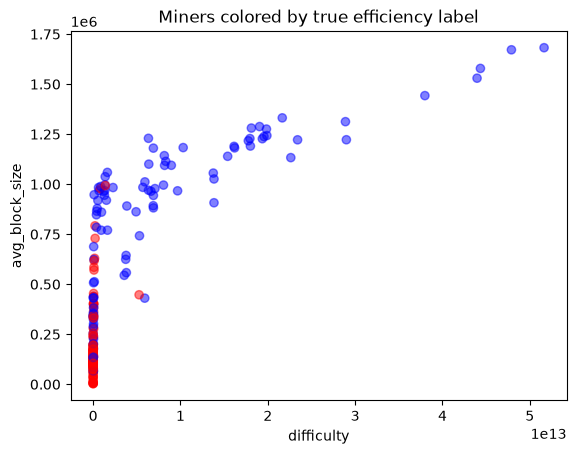

In [53]:
import matplotlib.pyplot as plt

plt.scatter(X_test_raw['difficulty'], X_test_raw['avg_block_size'], c=label_colors, alpha=0.5)
# plt.xscale('log')
# plt.yscale('log')
plt.xlabel('difficulty')
plt.ylabel('avg_block_size')
plt.title('Miners colored by true efficiency label')
plt.show()

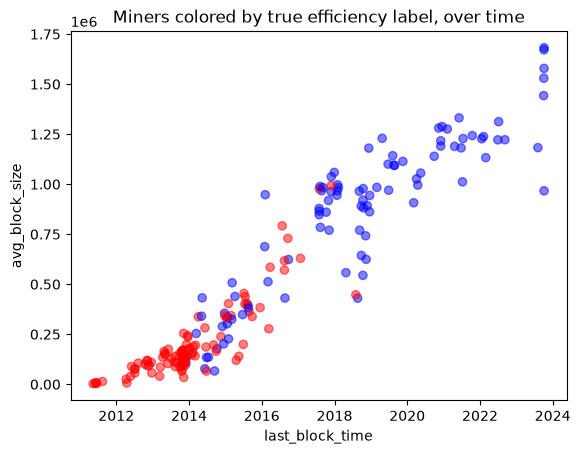

In [54]:
plt.scatter(X_test_raw['last_block_time'], X_test_raw['avg_block_size'], c=label_colors, alpha=0.5)
plt.xlabel('last_block_time')
plt.ylabel('avg_block_size')
plt.title('Miners colored by true efficiency label, over time')
plt.show()

In [55]:
X_test_raw['mean_of_ratios_efficiency'].corr(X_test_raw['last_block_time'].astype('int64'))

np.float64(0.4956328081503338)

In [57]:
drop_features.sort_values('last_block_time')['label_mor'].reset_index(drop=True)

0      0
1      0
2      0
3      0
4      0
      ..
970    1
971    1
972    1
973    1
974    1
Name: label_mor, Length: 975, dtype: int64

In [58]:
sorted_labels = drop_features.sort_values('last_block_time')['label_mor'].reset_index(drop=True)
split_point = int(len(sorted_labels) * 0.8)

print("Train (earliest 80%):")
print(sorted_labels[:split_point].value_counts())

print("\nTest (most recent 20%):")
print(sorted_labels[split_point:].value_counts())

Train (earliest 80%):
label_mor
0    487
1    293
Name: count, dtype: int64

Test (most recent 20%):
label_mor
1    194
0      1
Name: count, dtype: int64


In [56]:
# --- Verify that satoshi vs BTC units don't change the efficiency labels ---
SATOSHIS_PER_BTC = 1e8

for name, df in [('bucket_features', bucket_features), ('drop_features', drop_features)]:

    # mean_of_ratios_efficiency was built from block_efficiency = transaction_count / total_output_satoshis
    # (satoshis). Multiplying by SATOSHIS_PER_BTC is equivalent to having divided by BTC-denominated
    # volume in the first place (linearity of mean survives a constant per-row scaling).
    eff_satoshi = df['mean_of_ratios_efficiency']
    eff_btc = eff_satoshi * SATOSHIS_PER_BTC

    labels_satoshi = (eff_satoshi > eff_satoshi.median()).astype(int)
    labels_btc = (eff_btc > eff_btc.median()).astype(int)

    print(f"{name} (mean_of_ratios): labels identical = {(labels_satoshi == labels_btc).all()}, "
          f"mismatches = {(labels_satoshi != labels_btc).sum()}")
    print(f"{name}: recomputed label matches stored label_mor = {(labels_satoshi == df['label_mor']).all()}")

    # same check for ratio_of_means_efficiency = avg_transactions / avg_volume (avg_volume in satoshis)
    rom_satoshi = df['ratio_of_means_efficiency']
    rom_btc = df['avg_transactions'] / ((df['avg_volume'] / SATOSHIS_PER_BTC) + 1e-9)

    labels_rom_satoshi = (rom_satoshi > rom_satoshi.median()).astype(int)
    labels_rom_btc = (rom_btc > rom_btc.median()).astype(int)

    print(f"{name} (ratio_of_means): labels identical = {(labels_rom_satoshi == labels_rom_btc).all()}\n")

bucket_features (mean_of_ratios): labels identical = True, mismatches = 0
bucket_features: recomputed label matches stored label_mor = True
bucket_features (ratio_of_means): labels identical = True

drop_features (mean_of_ratios): labels identical = True, mismatches = 0
drop_features: recomputed label matches stored label_mor = True
drop_features (ratio_of_means): labels identical = True



In [59]:
drop_features.head()

,miner_id,blocks_mined,avg_transactions,avg_volume,avg_block_size,difficulty,mean_of_ratios_efficiency,avg_fee_proxy,fee_volatility_proxy,profitability_proxy,avg_fee_real,fee_volatility_real,profitability_real,last_block_time,ratio_of_means_efficiency,age,label_rom,label_mor
0,112th1SmjAKALwtpsdXuYQ4Uu8e9rbwEXt,20,307.800000,4.959150e+11,1.454196e+05,1.364458e+09,1.116369e-09,2.504812e+14,4.047109e+14,2.385536e+14,6.680948e+06,6.176548e+06,6.362807e+06,2014-02-07 07:32:28+00:00,6.206709e-10,30068.0,0,0
1,1134jVdutTZpDfsPjLu4U1vE3UURdWeFui,15,1122.666667,1.409796e+12,1.050330e+06,2.686701e+12,1.783455e-09,2.530541e+15,4.328295e+15,2.372383e+15,7.316809e+07,6.592820e+07,6.859508e+07,2018-02-17 00:21:45+00:00,7.963325e-10,551120.0,0,1
2,115ZtZBrhso9PbHBUh44gf6ycxmoHHEFp1,516,276.662791,5.842798e+12,1.172129e+05,2.775592e+06,3.564871e-10,2.622663e+15,1.443940e+16,2.617590e+15,2.423655e+07,7.490265e+07,2.418967e+07,2012-11-06 19:07:36+00:00,4.735108e-11,218.0,0,0
3,11wC5KcbgrWRBb43cwADdVrxgyF8mndVC,92,2248.413043,1.167290e+12,1.201610e+06,1.753234e+13,5.539491e-09,2.943857e+15,4.023023e+15,2.912202e+15,5.257164e+07,4.448954e+07,5.200635e+07,2020-10-26 20:11:49+00:00,1.926183e-09,1097702.0,1,1
4,122Z63d9uRgYaAugxawaB79o12fRNYwFc8,125,905.792000,7.026907e+11,4.629104e+05,3.638500e+12,2.207158e-09,1.143534e+15,2.363713e+15,1.134458e+15,4.419493e+07,8.027681e+07,4.384417e+07,2018-11-30 15:33:32+00:00,1.289034e-09,261252.0,1,1
